## Thesis plots

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

from sklearn.metrics import root_mean_squared_error


base_dir = os.path.dirname(os.path.abspath(""))
thesis_fig_folder = os.path.join(base_dir, 'Thesis report', 'figures_thesis')

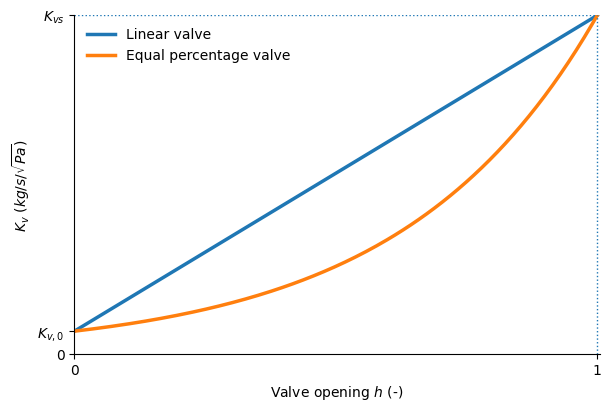

In [2]:
# -----------------------
# Ideal valve functions
# -----------------------

def linear_valve_func(h, Kvs, Kv0):
    return Kv0 + h * (Kvs - Kv0)


def equal_percentage_ideal(h, Kvs, Kv0):
    return (Kvs / Kv0) ** (h - 1) * Kvs


# -----------------------
# Parameters
# -----------------------

h_array = np.linspace(0, 1, 200)

Kvs = 0.003
Kv0 = Kvs / 15   # or Kvs/25 depending on your definition

Kv_linear = linear_valve_func(h_array, Kvs, Kv0)
Kv_equal = equal_percentage_ideal(h_array, Kvs, Kv0)

# -----------------------
# Plot
# -----------------------

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

ax.plot(h_array, Kv_linear, lw=2.5, label='Linear valve')
ax.plot(h_array, Kv_equal, lw=2.5, label='Equal percentage valve')

ax.plot([0,1], [Kvs, Kvs], color='C0',ls = ':', lw=1)
ax.plot([1,1], [0, Kvs], color='C0', ls = ':', lw=1)

# Limits
ax.set_xlim(0, 1.005)
ax.set_ylim(0, Kvs)

# Labels
ax.set_xlabel(r'Valve opening $h$ (-)')
ax.set_ylabel(r'$K_v$ $(kg/s/\sqrt{Pa}$)')

# Clean ticks
ax.set_xticks([0, 1])
ax.set_xticklabels(['0', '1'])

ax.set_yticks([0, Kv0, Kvs])
ax.set_yticklabels(['0', r'$K_{v,0}$', r'$K_{vs}$'])

# Style
# ax.grid(alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False)

plt.savefig(os.path.join(thesis_fig_folder, 'Kvplots_ideal.png'), dpi=150, bbox_inches='tight')
plt.show()

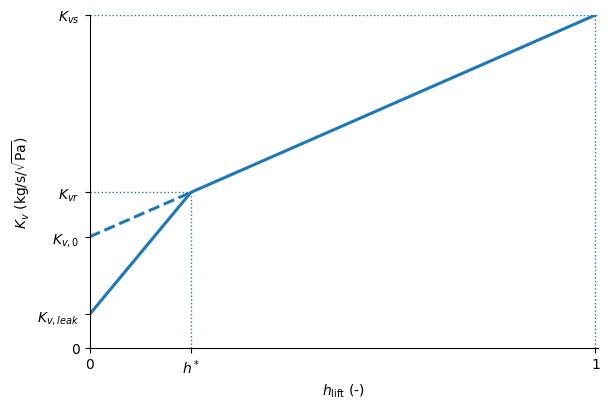

In [3]:
# -----------------------
# Parameters
# -----------------------
Kvs = 1
Kv0 = Kvs / 3
Kv_leak = Kvs / 10
h_star = 0.2

# -----------------------
# Ideal characteristics
# -----------------------
def linear_valve_func(h, Kvs, Kv0, Kvleak, h_star):
    def linear_ideal_func(h):
        return h * (Kvs - Kv0) + Kv0

    if h < h_star:
        Kv = Kvleak + h*(linear_ideal_func(h_star) - Kvleak)/h_star
    else:
        Kv = linear_ideal_func(h)
    return Kv

# -----------------------
# Data
# -----------------------
h_array = np.linspace(0, 1, 500)
Kv_lin_array = np.zeros(len(h_array))
Kv_ideal_lin_array = np.zeros(len(h_array))
for i,h in enumerate(h_array):
    Kv_lin_array[i] = linear_valve_func(h, Kvs, Kv0, Kv_leak, h_star)
    Kv_ideal_lin_array[i] = linear_valve_func(h, Kvs, Kv0, Kv_leak, 0)

# key point at h*
Kvr = linear_valve_func(h_star, Kvs, Kv0, Kv_leak, h_star)

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(6.2, 4.2))

# Curves
ax.plot(h_array, Kv_lin_array, color='C0', lw=2.2, label='Linear')
ax.plot(h_array[h_array < h_star], Kv_ideal_lin_array[h_array < h_star], color='C0', ls = '--', lw=2.2)

# # Leakage / low-opening approximation (piecewise hint line)
# ax.plot([0, h_star], [Kv_leak,], color='C0', lw=1.2)

# Construction lines at h*
ax.plot([h_star, h_star], [0, Kvr], color='C0', ls=':', lw=1)
ax.plot([0, h_star], [Kvr, Kvr], color='C0', ls=':', lw=1)

ax.plot([0,1], [Kvs, Kvs], color='C0', ls = ':', lw=1)
ax.plot([1,1], [0, Kvs], color='C0', ls = ':', lw=1)

# -----------------------
# Text annotations
# -----------------------
# Clean ticks
ax.set_xticks([0,h_star, 1])
ax.set_xticklabels(['0', r'$h^*$', '1'])

ax.set_yticks([0, Kv_leak, Kv0, Kvr, Kvs])
ax.set_yticklabels(['0', r'$K_{v,leak}$', r'$K_{v,0}$', r'$K_{vr}$', r'$K_{vs}$'])

# -----------------------
# Axes styling
# -----------------------
ax.set_xlim(0, 1.005)
ax.set_ylim(0, Kvs)

ax.set_xlabel(r'$h_{\mathrm{lift}}$ (-)')
ax.set_ylabel(r'$K_v$ (kg/s/$\sqrt{\mathrm{Pa}}$)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(os.path.join(thesis_fig_folder, 'Kvplots_linear_real.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Actuator control

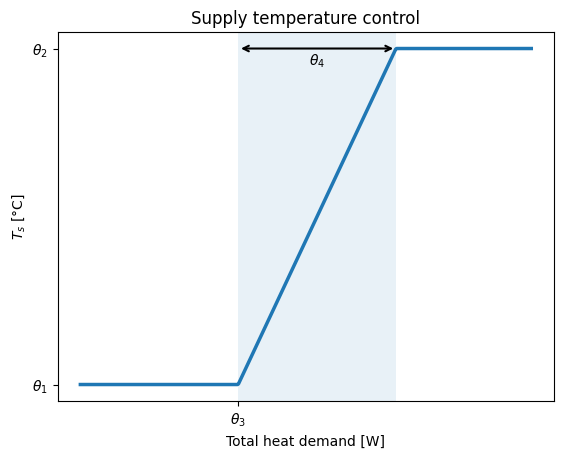

In [5]:
# X-axis
x = np.linspace(0, 200, 500)  # total heat demand [W]

# Supply temperature profile (decreasing)
T_sup = np.zeros_like(x)

T_sup_min = 60 # theta1
T_sup_max = 65 # theta2
P_band = 70 # theta3
P_band_end = 140 # theta4

for i, xi in enumerate(x):
    if xi < P_band_end - P_band:
        T_sup[i] = T_sup_min          # constant region
    elif xi <= P_band_end:
        T_sup[i] = T_sup_min + (xi - P_band_end + P_band) * (T_sup_max - T_sup_min) / (P_band)  # linear P-band
    else:
        T_sup[i] = T_sup_max          # saturated region

# Plot
plt.figure()
plt.plot(x, T_sup, lw = 2.5, color = 'C0')

plt.xlabel("Total heat demand [W]")
plt.ylabel(r"$T_s$ [°C]")
plt.title("Supply temperature control")
# Draw double arrow for P-band
plt.annotate(
    '', 
    xy=(P_band_end, T_sup_max),      # right end of P-band
    xytext=(P_band_end - P_band, T_sup_max),  # left end of P-band
    arrowprops=dict(arrowstyle='<->', linewidth=1.5)
)

# Label the P-band
plt.text((P_band_end - P_band + P_band_end) / 2, T_sup_max - 0.25, r'$\theta_4$', ha='center')

ax = plt.gca()
# ax.axhline(55, linestyle='--', linewidth=1.5)
# ax.text(
#     ax.get_xlim()[0], 55,
#     r' $T_{set}$',
#     va='center',
#     ha='left'
# )
# Y-axis thetas
plt.yticks([T_sup_min, T_sup_max], [r"$\theta_1$", r"$\theta_2$"])
# X-axis thetas
plt.xticks([P_band_end - P_band], [r"$\theta_3$"])
plt.axvspan(P_band_end - P_band, P_band_end, alpha=0.1)

plt.savefig(os.path.join(thesis_fig_folder, 'supply_control.png'), dpi=150, bbox_inches='tight')

plt.show()


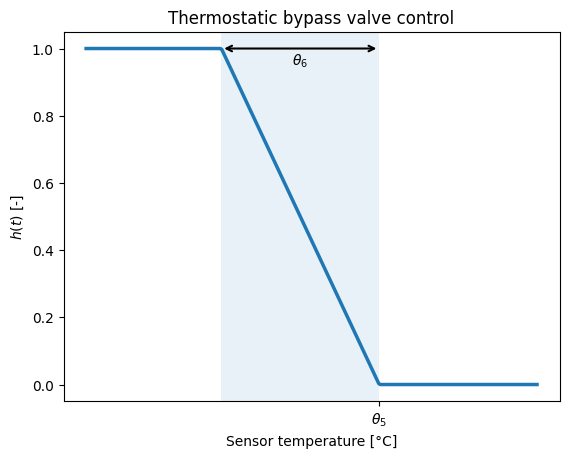

In [ ]:
# X-axis
x = np.linspace(50, 60, 300)

# Supply temperature profile (decreasing)
h_valve = np.zeros_like(x)

P_band_start = 53
P_band_end = 56.5

for i, xi in enumerate(x):
    if xi < P_band_start:
        h_valve[i] = 1   # high constant region (θ2)
    elif xi <= P_band_end:
        h_valve[i] = 1 - (xi - P_band_start) / (P_band_end - P_band_start)  # linear decrease
    else:
        h_valve[i] = 0   # low constant region (θ1)

# Plot
plt.figure()
plt.plot(x, h_valve, lw = 2.5, color = 'C0')

plt.xlabel("Sensor temperature [°C]")
plt.ylabel(r"$h(t)$ [-]")
plt.title("Thermostatic bypass valve control")

# Draw double arrow for P-band
plt.annotate(
    '', 
    xy=(P_band_end, 1.0),      # right end of P-band
    xytext=(P_band_start, 1.0),  # left end of P-band
    arrowprops=dict(arrowstyle='<->', linewidth=1.5)
)

# Label the P-band
plt.text((P_band_start + P_band_end) / 2, 0.95, r'$\theta_6$', ha='center')

# X-axis thetas
plt.xticks([P_band_end], [r"$\theta_5$"])
plt.axvspan(P_band_start, P_band_end, alpha=0.1)

plt.savefig(os.path.join(thesis_fig_folder, 'bypass_valve_control.png'), dpi=300, bbox_inches='tight')
plt.show()



# Pipeline verification

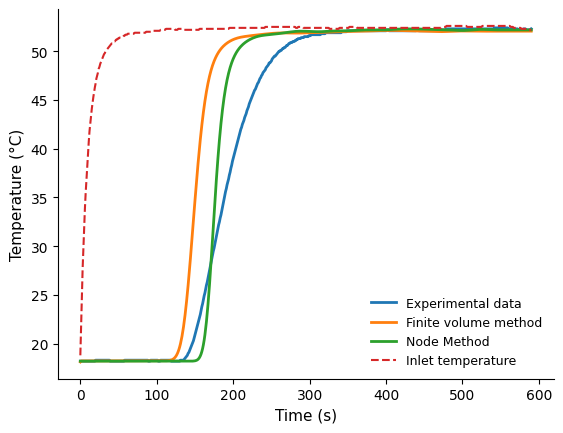

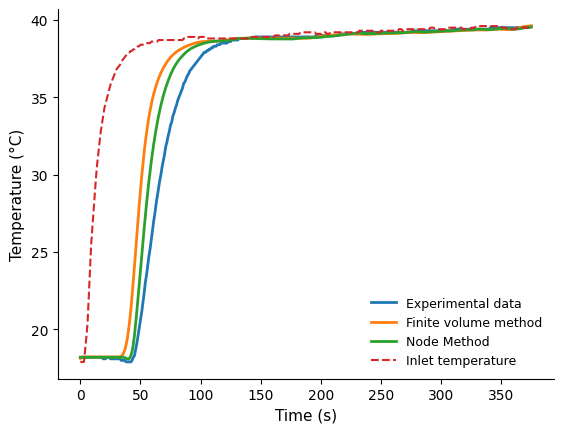

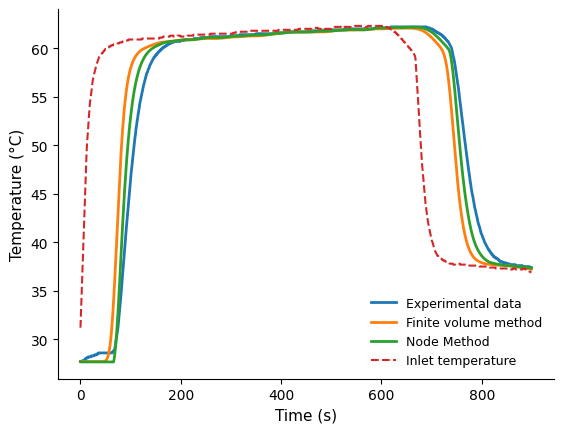

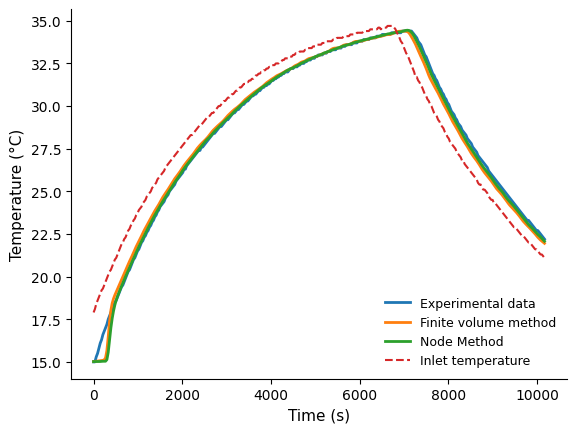

In [ ]:
## Obtain saved data 

folder = os.path.join(base_dir, "figures", "pipe_validation", "exp_simulation_modelica")

experiments = ['A', 'B', 'C', "D"]

for file in experiments:

    if file != 'D':
        dt = '1' 
    else: 
        dt = '30'
    folder_experiment = os.path.join(folder, f'Experiment{file}_dt={dt}_Tambt=18')

    data = pd.read_csv(os.path.join(folder_experiment,'comparison_data.csv'))

    mo_temp = data['Modelica temp']
    real_temp = data['Exp temp']
    nm_temp = data['Simulation temp']

    time = data['Time']
    Tin = data['Input temp simulation']

    plt.figure()

    plt.plot(time,real_temp, label = "Experimental data", lw = 2)
    plt.plot(time,mo_temp, label = f'Finite Volume Method', lw = 2)
    plt.plot(time,nm_temp, label = f'Node Method', lw = 2)
    plt.plot(time,Tin, label = 'Inlet temperature',linestyle = '--')
    # print(f"Experiment {file}: RMSE Modelica: {round(root_mean_squared_error(real_temp,mo_temp),2)}, RMSE Node Method: {round(root_mean_squared_error(real_temp, nm_temp),2)}")

    # plt.title(f"Temperature comparison: Experiment {file} ")
    plt.xlabel('Time (s)')
    plt.ylabel('Temperature (°C)')
    plt.legend()
    # plt.grid(True)
    plt.savefig(os.path.join(thesis_fig_folder, f'experiment{file}.png'))
    plt.savefig(os.path.join(thesis_fig_folder, f'experiment{file}.pdf'))

    plt.show()




# Results 

In [3]:
def format_plot_time_axis(num_hours=24):
    """
    Format plot time axis to show hours with ticks every 4 hours.
    
    Args:
        dt: time step in seconds
        num_hours: total time in hours (default 24)
    """
    ax = plt.gca()
    ax.set_xlim(0, num_hours * 3600)  # limits in seconds
    ticks_seconds = np.arange(0, num_hours + 1, 4) * 3600
    ax.set_xticks(ticks_seconds)
    ax.set_xticklabels([f'{int(h)}' for h in np.arange(0, num_hours + 1, 4)])


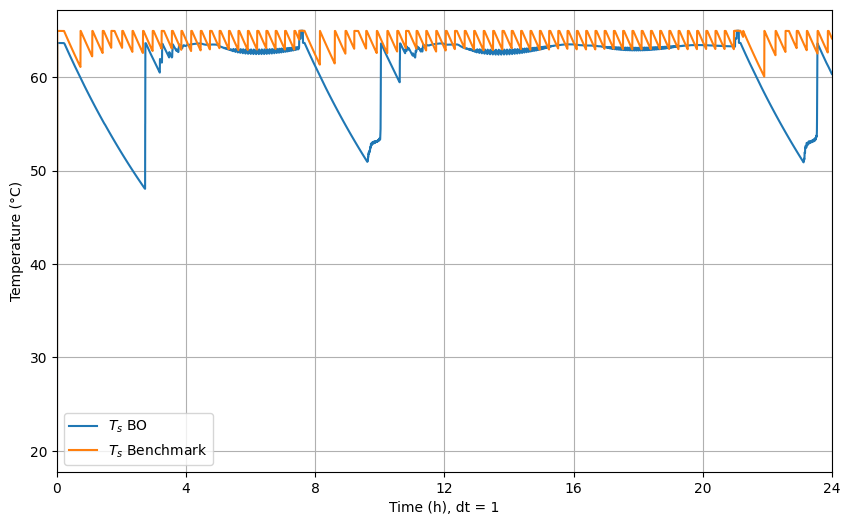

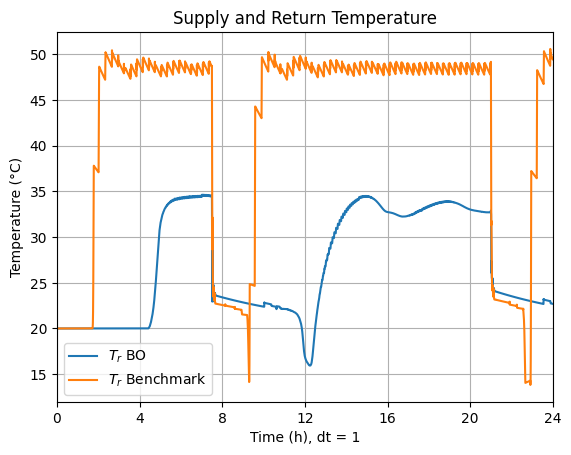

In [5]:
profile = 'Profile 1'
n_init_points = 10
n_iter = 15
dt = 1

day_str = '2026-07-06'

# bench folder
bench_folder_name = f'Benchmark_{profile}_dt={dt}'
bench_folder = os.path.join(base_dir, 'figures', 'benchmark', bench_folder_name)
      
# Opt folder
opt_folder_name = f'{profile}_dt={dt}_init_points={n_init_points}_n_iter={n_iter}'
opt_folder = os.path.join(base_dir, 'figures', 'optimization_set', day_str, opt_folder_name)

file_opt = os.path.join(opt_folder, 'hex_consumer_data', 'total_heat.csv')

# Return and supply temperature 
opt_temp_path = os.path.join(opt_folder, 'simulation_data','Node_temp.csv')
opt_temp_df = pd.read_csv(opt_temp_path)

bench_temp_path = os.path.join(bench_folder, 'simulation_data','Node_temp.csv')
bench_temp_df = pd.read_csv(bench_temp_path)

time = opt_temp_df['time'].values
fig_T_in = plt.figure(figsize=(10, 6))
plt.plot(time, opt_temp_df['Node 1.1'], label = r"$T_s$ BO")
plt.plot(time, bench_temp_df['Node 1.1'], label = r"$T_s$ Benchmark")
plt.xlabel(f'Time (h)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
format_plot_time_axis()

plt.figure()
plt.plot(time, opt_temp_df['Node 1.6'], label = r"$T_r$ BO")
plt.plot(time, bench_temp_df['Node 1.6'], label = r"$T_r$ Benchmark")
plt.title('Supply and Return Temperature')     
plt.xlabel(f'Time (h)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
format_plot_time_axis()
    
# plt.savefig(os.path.join(output_folder, 'supply_return_temperature.png'))
plt.show()


# # Bypass valve displacement
# opt_bypass_path = os.path.join(opt_folder, 'hex_consumer_data','bypass.csv')
# opt_bypass_df = pd.read_csv(opt_bypass_path)

# bench_bypass_path = os.path.join(bench_folder, 'hex_consumer_data','bypass.csv')
# bench_bypass_df = pd.read_csv(bench_bypass_path)    

# fig_bypass_h = plt.figure(figsize=(10, 6)) 
# plt.plot(time, opt_bypass_df['h'], label = "BO")
# plt.plot(time, bench_bypass_df['h'], label = "Benchmark")
# plt.title("Bypass Valve Displacement") 
# plt.xlabel(f'Time (h), dt = {dt}')
# plt.ylabel('Valve displacement (-)')
# plt.legend()
# plt.grid(True)
# format_plot_time_axis()

# plt.savefig(os.path.join(output_folder, 'bypass_displacement.png'))
# plt.close()

# # Bypass valve temperature
# fig_bypass_T = plt.figure(figsize=(10, 6))
# plt.plot(time, opt_bypass_df['T node'], label = "BO")
# plt.plot(time, bench_bypass_df['T node'], label = "Benchmark")
# plt.title("Bypass Valve Temperature")
# plt.xlabel(f'Time (h), dt = {dt}')
# plt.ylabel('Temperature (°C)')
# plt.legend()
# plt.grid(True)
# format_plot_time_axis()

# plt.savefig(os.path.join(output_folder, 'bypass_temperature.png'))
# plt.close()

# # Total heat demand and supply
# opt_heat_path = os.path.join(opt_folder, 'hex_consumer_data','total_heat.csv')
# opt_heat_df = pd.read_csv(opt_heat_path)

# bench_heat_path = os.path.join(bench_folder, 'hex_consumer_data','total_heat.csv')
# bench_heat_df = pd.read_csv(bench_heat_path)    

# diff_opt = np.sum(opt_heat_df["Supply"].values - opt_heat_df["Demand"].values)
# diff_bench = np.sum(bench_heat_df["Supply"].values - bench_heat_df["Demand"].values)

# fig_heat = plt.figure(figsize=(10, 6))

# # Calculate total heat demand and supply for BO  
# plt.plot(time, opt_heat_df["Demand"]/1e3, label='Total Heat Demand')
# plt.plot(time, opt_heat_df["Supply"]/1e3, label= "Total Heat Supply BO " + r"$\Delta Q$ = " + f"{round(diff_opt)/1e3:.3f} kJ", linestyle='--')
# plt.plot(time, bench_heat_df["Supply"]/1e3, label='Total Heat Supply Benchmark ' + r"$\Delta Q$ =" + f"{round(diff_bench)/1e3:.3f} kJ", linestyle='--')

# plt.title('Total Heat Demand vs Supply')     
# plt.xlabel(f'Time (h), dt = {dt}')
# plt.ylabel('Heat (kW)')
# plt.legend()
# plt.grid(True)
# format_plot_time_axis()

# plt.savefig(os.path.join(output_folder, 'total_heat_demand_supply.png'))
# plt.close()

In [18]:
def format_plot_time_axis(num_hours=24, ax=None, left_pad_frac=0.01):
    if ax is None:
        ax = plt.gca()
    total_seconds = num_hours * 3600
    pad = left_pad_frac * total_seconds
    ax.set_xlim(-pad, total_seconds)
    ticks_seconds = np.arange(0, num_hours + 1, 4) * 3600
    ax.set_xticks(ticks_seconds)
    ax.set_xticklabels([f'{int(h)}' for h in np.arange(0, num_hours + 1, 4)])


In [21]:
import matplotlib.pyplot as plt


In [ ]:
dict_Ts = {}
dict_Tr = {}


for i in range(1,5):

    profile = f'Profile {i}'
    n_init_points = 10
    n_iter = 15
    dt = 1

    day_str_list = ['2026-07-06', '2026-07-07', '2026-07-08']
    alpha = [0.25,0.15,0.05]

    if profile == 'Profile 1':
        day_str_list = day_str_list[:2]
        alpha = alpha[:2]

    bench_plot = False
    for i, day_str in enumerate(day_str_list):
        alpha_val = alpha[i]

        # bench folder
        bench_folder_name = f'Benchmark_{profile}_dt={dt}'
        bench_folder = os.path.join(base_dir, 'figures', 'benchmark', bench_folder_name)

        # Opt folder
        opt_folder_name = f'{profile}_dt={dt}_init_points={n_init_points}_n_iter={n_iter}'
        opt_folder = os.path.join(base_dir, 'figures', 'optimization_set', day_str, opt_folder_name)

        file_opt = os.path.join(opt_folder, 'hex_consumer_data', 'total_heat.csv')

        # Return and supply temperature
        opt_temp_path = os.path.join(opt_folder, 'simulation_data','Node_temp.csv')
        opt_temp_df = pd.read_csv(opt_temp_path)

        bench_temp_path = os.path.join(bench_folder, 'simulation_data','Node_temp.csv')
        bench_temp_df = pd.read_csv(bench_temp_path)
        
        dict_Ts[f'{profile}_{alpha_val}'] = opt_temp_df['Node 1.1'].values
        dict_Tr[f'{profile}_{alpha_val}'] = opt_temp_df['Node 1.6'].values

        dict_Ts[f'{profile}_bench'] = bench_temp_df['Node 1.1'].values
        dict_Tr[f'{profile}_bench'] = bench_temp_df['Node 1.6'].values


        # ax_r.plot(time, opt_temp_df['Node 1.6'], lw=1.5, ls = '--', label=str(alpha_val))

C:\Users\piete\AppData\Local\Temp\ipykernel_5148\2824239248.py:61: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
C:\Users\piete\AppData\Local\Temp\ipykernel_5148\2824239248.py:61: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
C:\Users\piete\AppData\Local\Temp\ipykernel_5148\2824239248.py:61: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


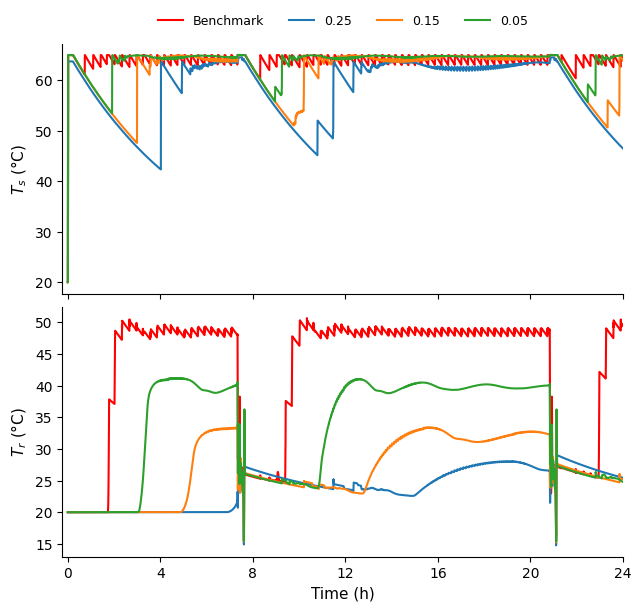

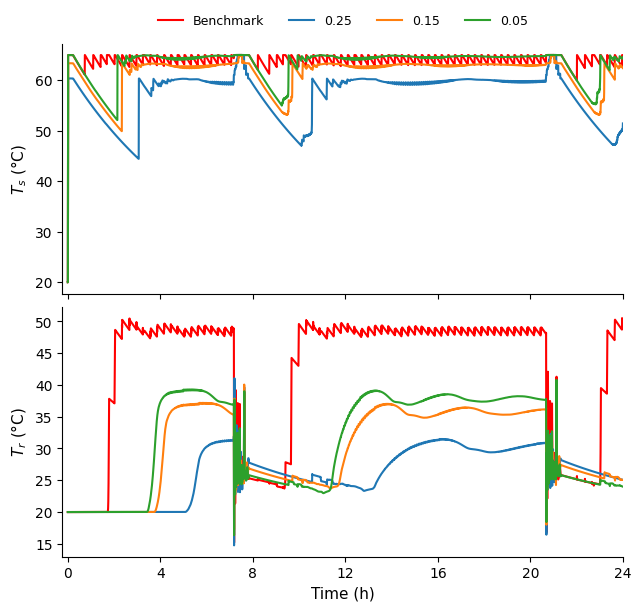

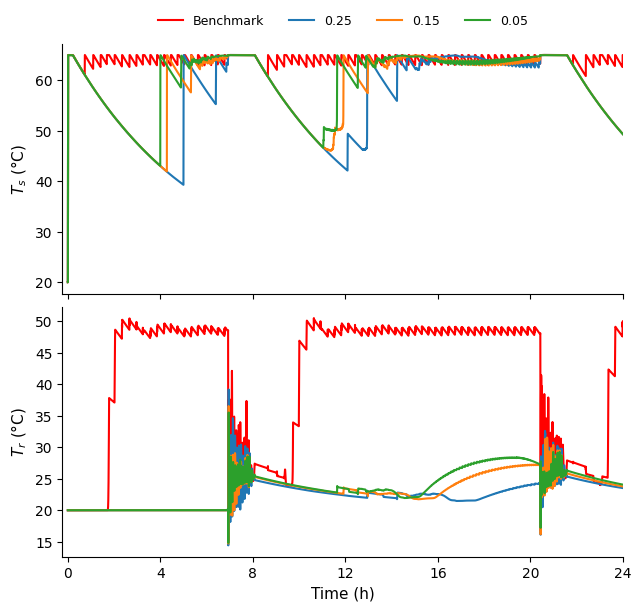

In [ ]:
# Set once, near the top of the file/notebook (matches your thesisplots.ipynb style block)
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
})

for i in range(1,5):

    profile = f'Profile {i}'
    n_init_points = 10
    n_iter = 15
    dt = 1

    day_str_list = ['2026-07-06', '2026-07-07', '2026-07-08']
    alpha = [0.25,0.15,0.05]

    if profile == 'Profile 1':
        day_str_list = day_str_list[:2]
        alpha = alpha[:2]

    # fig_s, ax_s = plt.subplots(figsize=(6, 4), constrained_layout=True)
    # fig_r, ax_r = plt.subplots(figsize=(6, 4), constrained_layout=True)
    fig, (ax_s, ax_r) = plt.subplots(
    2, 1, figsize=(6.3, 6), constrained_layout=True, sharex=True
)

    bench_plot = False
    for k, day_str in enumerate(day_str_list):
        alpha_val = alpha[k]

        if not bench_plot:
            ax_s.plot(time, dict_Ts[f'{profile}_bench'], color='red', lw=1.5, label='Benchmark')
            ax_r.plot(time, dict_Tr[f'{profile}_bench'], color='red', lw=1.5, label='Benchmark')
            bench_plot = True

        ax_s.plot(time, dict_Ts[f'{profile}_{alpha_val}'], lw=1.5, label=str(alpha_val))
        ax_r.plot(time, dict_Tr[f'{profile}_{alpha_val}'], lw=1.5, label=str(alpha_val))

    ax_s.set_ylabel(r'$T_s$ (°C)')
    # ax_s.set_xlabel('Time (h)')
    ax_s.legend(loc='best')
    format_plot_time_axis(ax=ax_s)

    ax_r.set_ylabel(r'$T_r$ (°C)')
    ax_r.set_xlabel('Time (h)')
    # ax_r.legend(loc='best')
    format_plot_time_axis(ax=ax_r)

    # Below the plot, centered, in a horizontal row
    ax_s.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)

    # Above the plot
    ax_s.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4)

    fig.show()
    # fig_r.show()

    fig.savefig(os.path.join(thesis_fig_folder, f'return_supply_temperature_profile_{i}.pdf'), bbox_inches='tight')



C:\Users\piete\AppData\Local\Temp\ipykernel_5148\3847846985.py:48: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_s.show()


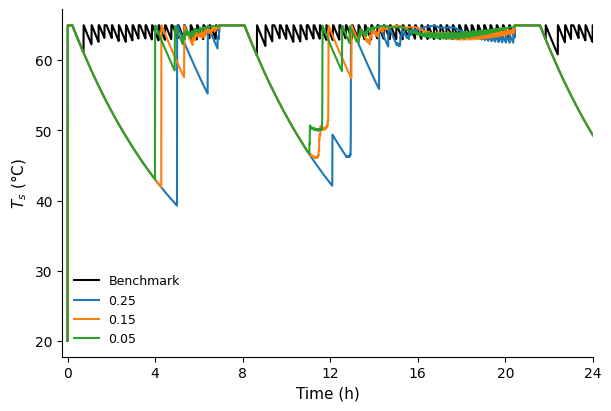

In [44]:
# Set once, near the top of the file/notebook (matches your thesisplots.ipynb style block)
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
})

for i in range(2,3):

    profile = f'Profile {i}'
    n_init_points = 10
    n_iter = 15
    dt = 1

    day_str_list = ['2026-07-06', '2026-07-07', '2026-07-08']
    alpha = [0.25,0.15,0.05]

    fig_s, ax_s = plt.subplots(figsize=(6, 4), constrained_layout=True)
    # fig_r, ax_r = plt.subplots(figsize=(6, 4), constrained_layout=True)

    bench_plot = False
    for i, day_str in enumerate(day_str_list):
        alpha_val = alpha[i]

        if not bench_plot:
            ax_s.plot(time, dict_Ts['bench'], color='black', lw=1.5, label='Benchmark')
            # ax_r.plot(time, dict_Tr['bench'], color='black', lw=1.5, label='Benchmark')
            bench_plot = True

        ax_s.plot(time, dict_Ts[alpha_val], lw=1.5, label=str(alpha_val))
        # ax_r.plot(time, dict_Tr[alpha_val], lw=1.5, ls = '--', label=str(alpha_val))

    ax_s.set_ylabel(r'$T_s$ (°C)')
    ax_s.set_xlabel('Time (h)')
    ax_s.legend(loc='best')
    format_plot_time_axis(ax=ax_s)

    # ax_r.set_ylabel(r'$T_r$ (°C)')
    # ax_r.set_xlabel('Time (h)')
    # ax_r.legend(loc='best')
    # format_plot_time_axis(ax=ax_r)

    fig_s.show()
    # fig_r.show()

    # fig_s.savefig(os.path.join(output_folder, 'supply_temperature.pdf'), bbox_inches='tight')
    # fig_r.savefig(os.path.join(output_folder, 'return_temperature.pdf'), bbox_inches='tight')

